In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from abc import ABC, abstractmethod

In [2]:
q = QuantumRegister(4, 'q')
c = ClassicalRegister(2, 'c')
qc = QuantumCircuit(q, c)

# Create initial entangled pair between q[0] and q[1]
qc.h(q[0])
qc.cx(q[0], q[1])  # Now q[0] and q[1] are in Bell state

# Create teleportation resource pair between q[2] and q[3]
qc.h(q[2])
qc.cx(q[2], q[3])  # Now q[2] and q[3] are in Bell state

# Teleportation protocol
# Use q[2] and q[3] to teleport q[1]'s state
qc.barrier()  # Adding barrier for clarity
qc.cx(q[1], q[2])  # Bell measurement part 1
qc.h(q[1])        # Bell measurement part 2
qc.measure(q[1], c[0])
qc.measure(q[2], c[1])

# Corrective operations on q[3]
qc.x(q[3]).c_if(c[1], 1)
qc.z(q[3]).c_if(c[0], 1)

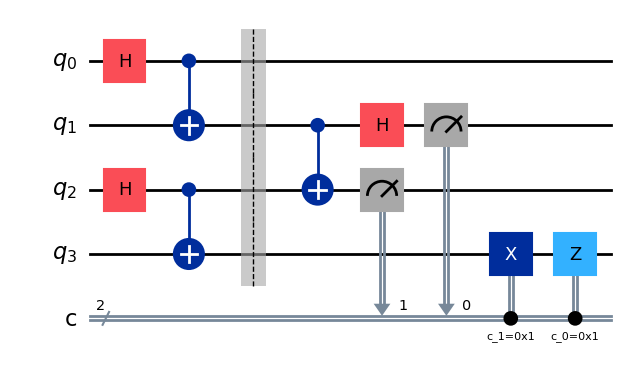

In [3]:
qc.draw(output="mpl")